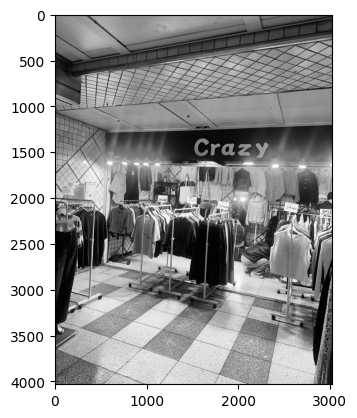

In [1]:
##이미지 확인 및 라이브러리
import cv2
import matplotlib.pyplot as plt
import numpy as np
from skimage.metrics import structural_similarity as ssim

img = cv2.imread('practicepic.jpg', cv2.IMREAD_GRAYSCALE)

plt.imshow(img, cmap='gray')
plt.show()

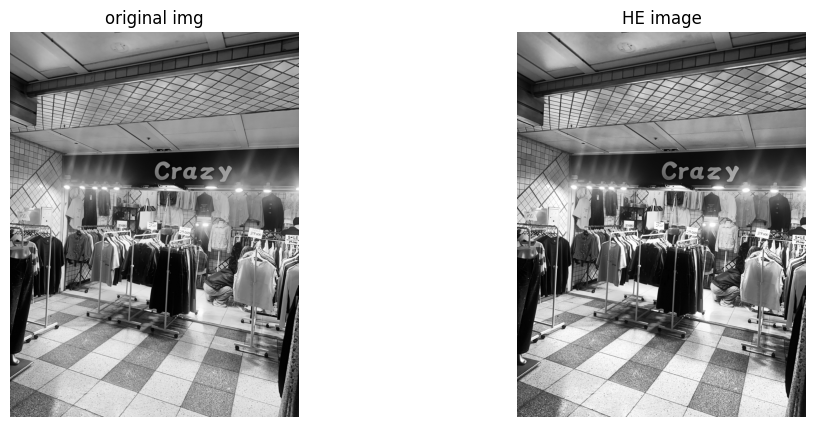

/tmp/ipykernel_5620/3799427568.py:25: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(img.ravel(), 256, [0, 256])
/tmp/ipykernel_5620/3799427568.py:29: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(img_he.ravel(), 256, [0, 256])


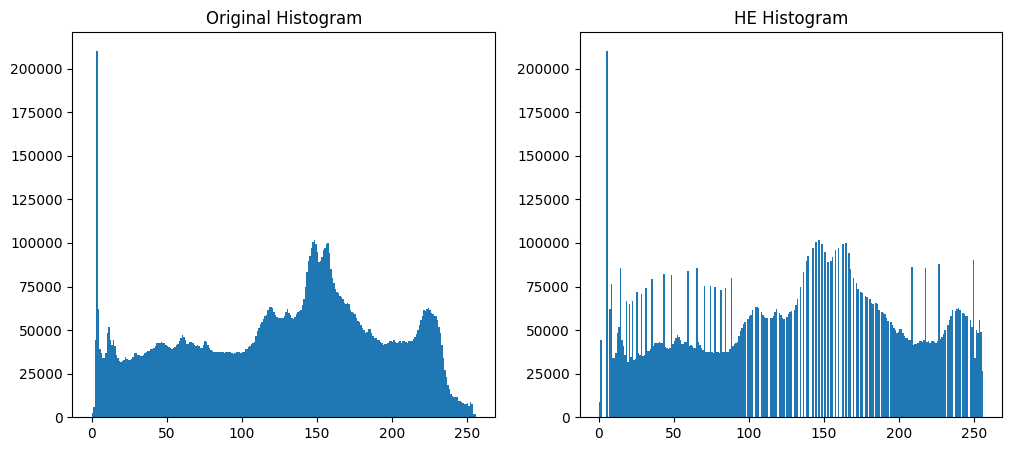

지표 결과 출력
MSE: 125.8302
PSNR: 27.1330 dB
SSIM: 0.9738


In [5]:
# HE 적용
img_he = cv2.equalizeHist(img)

#가로로 넓게 사진 비교
plt.figure(figsize=(12, 5))

# 원본 사진 출력
plt.subplot(1, 2, 1)
plt.imshow(img, cmap='gray')
plt.title("Original image")
plt.axis('off') #눈금 OFF

# 우측에 HE 적용 사진 출력
plt.subplot(1, 2, 2)
plt.imshow(img_he, cmap='gray')
plt.title("HE image")
plt.axis('off')

plt.show()

# HE 그래프 출력
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(img.ravel(), 256, [0, 256])
plt.title("Original Histogram")

plt.subplot(1, 2, 2)
plt.hist(img_he.ravel(), 256, [0, 256])
plt.title("HE Histogram")

plt.show()

# MSE 계산float으로
mse_he = np.mean((img.astype(np.float64) - img_he.astype(np.float64)) ** 2)

# PSNR 계산
psnr_he = cv2.PSNR(img, img_he)

# SSIM 계산
# data_range는 255로 통일했습니다.
ssim_he = ssim(img, img_he, data_range=255)

# 결과 출력
print(f"HE 적용 지표 결과 출력")
print(f"MSE: {mse_he:.4f}")
print(f"PSNR: {psnr_he:.4f} dB")
print(f"SSIM: {ssim_he:.4f}")

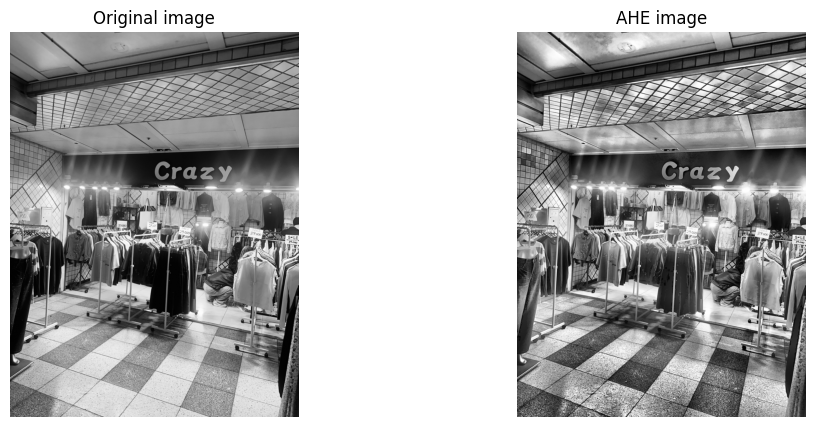

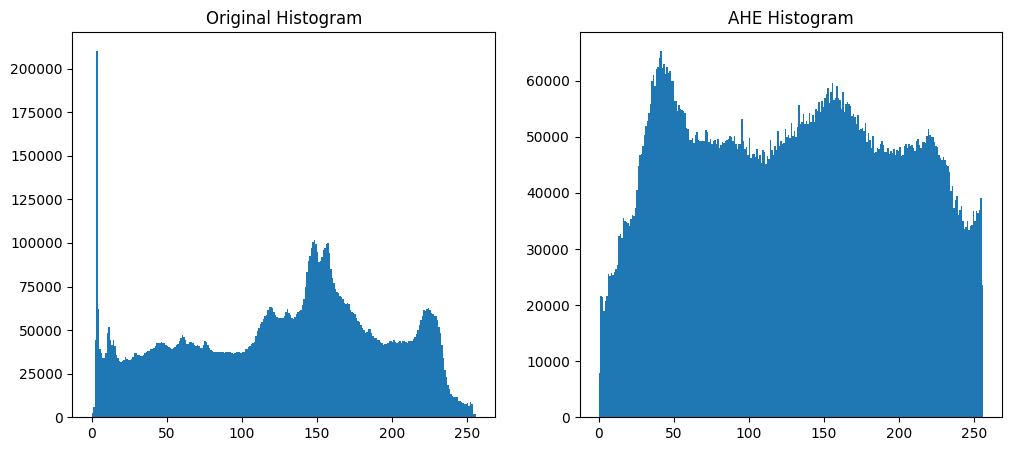

--- AHE 결과 지표 ---
MSE: 1400.6921
PSNR: 16.6674 dB
SSIM: 0.7856


In [6]:
# HE 도구 만들기
# 그리드 사이즈를 8,8로 나눔
# 리미트를 아주 높게줬기때문에 AHE가 됨(clipLimit)
ahe_tool = cv2.createCLAHE(clipLimit=40.0, tileGridSize=(8, 8))

# 사진에 적용하기
img_ahe = ahe_tool.apply(img)

# 결과 확인
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(img, cmap='gray')
plt.title("Original image")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(img_ahe, cmap='gray')
plt.title("AHE image")
plt.axis('off')

plt.show()

# 히스토그램을 위한 준비
plt.figure(figsize=(12, 5))

# 왼쪽은 원본 히스토그램
plt.subplot(1, 2, 1)
plt.hist(img.ravel(), 256, range=[0, 256])
plt.title("Original Histogram")

# 오른쪽 AHE 적용시킨 히스토그램
plt.subplot(1, 2, 2)
plt.hist(img_ahe.ravel(), 256, range=[0, 256])
plt.title("AHE Histogram")

plt.show()

# MSE 계산
mse_ahe = np.mean((img.astype(np.float64) - img_ahe.astype(np.float64)) ** 2)

# PSNR 계산
psnr_ahe = cv2.PSNR(img, img_ahe)

# SSIM 계산
ssim_ahe = ssim(img, img_ahe, data_range=255)

# 결과 출력
print(f"AHE 적용 지표 결과 출력")
print(f"MSE: {mse_ahe:.4f}")
print(f"PSNR: {psnr_ahe:.4f} dB")
print(f"SSIM: {ssim_ahe:.4f}")

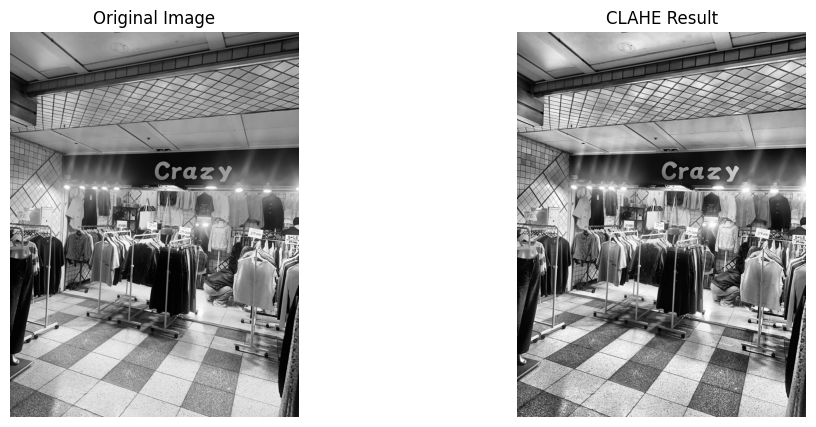

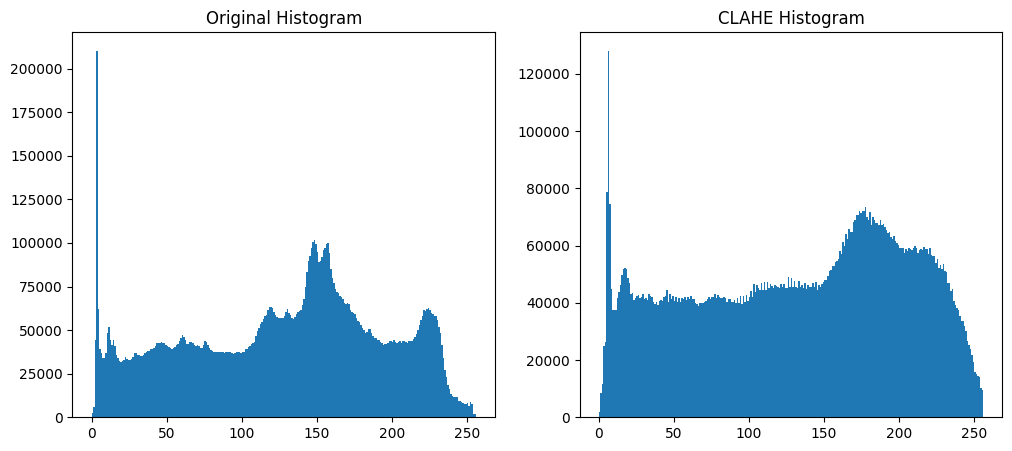

--- CLAHE 결과 지표 ---
MSE: 524.3808
PSNR: 20.9343 dB
SSIM: 0.9212


In [4]:
# CLAHE 준비
# clipLimit=2로 설정해서 대비가 너무 튀지 않게 노이즈를 줄여줌
# 이번에도 8x8로 구역 나눔
clahe_tool = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))

# 적용
img_clahe = clahe_tool.apply(img)

# 원본과 CLAHE 비교
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1); plt.imshow(img, cmap='gray'); plt.title("Original image"); plt.axis('off')
plt.subplot(1, 2, 2); plt.imshow(img_clahe, cmap='gray'); plt.title("CLAHE image"); plt.axis('off')
plt.show()

# 히스토그램 비교
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.hist(img.ravel(), 256, range=[0, 256])
plt.title("Original Histogram")

plt.subplot(1, 2, 2)
plt.hist(img_clahe.ravel(), 256, range=[0, 256])
plt.title("CLAHE Histogram")

plt.show()

# 평가지표 계산하기
mse_clahe = np.mean((img.astype(np.float64) - img_clahe.astype(np.float64)) ** 2)
psnr_clahe = cv2.PSNR(img, img_clahe)
ssim_clahe = ssim(img, img_clahe, data_range=255)

# 수치 결과 출력
print(f"CLAHE 적용 지표 결과 출력")
print(f"MSE: {mse_clahe:.4f}")
print(f"PSNR: {psnr_clahe:.4f} dB")
print(f"SSIM: {ssim_clahe:.4f}")